In [2]:
#installing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


Étape 1 : Exploration descriptive de la Target (rental_price_per_day)

In [3]:
# Loading Data from CSV
df_pricing = pd.read_csv("get_around_pricing_project.csv")
print(df_pricing.head())


# Supprimer l'index inutile s'il est présent
if df_pricing.columns[0] == "Unnamed: 0" or df_pricing.columns[0] == "":
    df_pricing = df_pricing.iloc[:, 1:]

print("--- SHAPE & COLUMNS ---")
print(f"Features count: {df_pricing.shape[1] - 1}")
print(f"Rows count: {df_pricing.shape[0]}")
print(df_pricing.info())

   Unnamed: 0 model_key  mileage  engine_power    fuel paint_color  \
0           0   Citroën   140411           100  diesel       black   
1           1   Citroën    13929           317  petrol        grey   
2           2   Citroën   183297           120  diesel       white   
3           3   Citroën   128035           135  diesel         red   
4           4   Citroën    97097           160  diesel      silver   

      car_type  private_parking_available  has_gps  has_air_conditioning  \
0  convertible                       True     True                 False   
1  convertible                       True     True                 False   
2  convertible                      False    False                 False   
3  convertible                       True     True                 False   
4  convertible                       True     True                 False   

   automatic_car  has_getaround_connect  has_speed_regulator  winter_tires  \
0          False                   True     

In [4]:
df_pricing.describe()

,mileage,engine_power,rental_price_per_day
count,4.843000e+03,4843.00000,4843.000000
mean,1.409628e+05,128.98823,121.214536
std,6.019674e+04,38.99336,33.568268
min,-6.400000e+01,0.00000,10.000000
25%,1.029135e+05,100.00000,104.000000
50%,1.410800e+05,120.00000,119.000000
75%,1.751955e+05,135.00000,136.000000
max,1.000376e+06,423.00000,422.000000


1. La Variable Cible (La "Target")
rental_price_per_day : C'est la valeur en euros que l'on veut deviner. C'est une variable numérique continue (elle peut prendre n'importe quelle valeur : 50€, 120€, 235€...).

Conclusion immédiate : Nous sommes face à un problème de Régression (et non de classification).

2. Les Variables Numériques Continues (Les Features quantitatives)
mileage (Kilométrage) et engine_power (Puissance du moteur).
Ces variables ont des échelles totalement différentes.Il faudra obligatoirement utiliser un StandardScaler pour les mettre sur la même échelle.

3. Les Variables Catégorielles (Les Features qualitatives & booléennes)
 - Les textes : model_key (la marque/modèle), fuel, paint_color, car_type.
 - Les booléens (True/False) : has_gps, has_air_conditioning, automatic_car, etc.
Nous allons devoir transformer ces catégories en chiffres via un encodage.

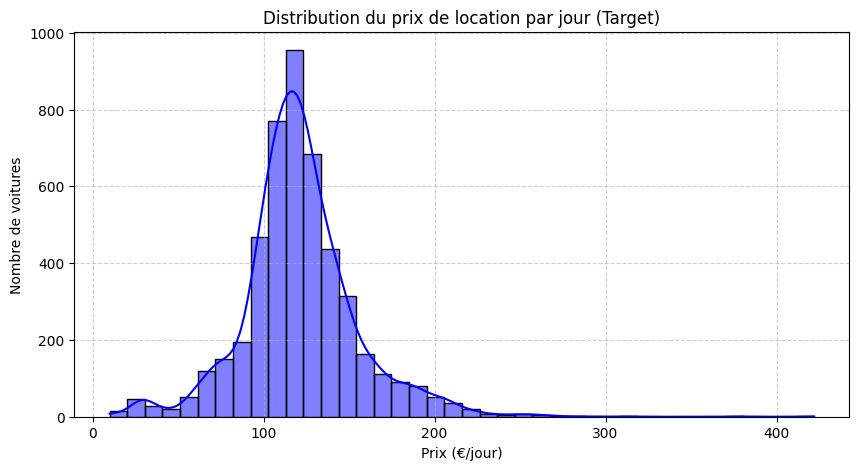

In [5]:
#  Visualisation graphique de la distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_pricing["rental_price_per_day"], kde=True, color="blue", bins=40)
plt.title("Distribution du prix de location par jour (Target)")
plt.xlabel("Prix (€/jour)")
plt.ylabel("Nombre de voitures")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Le min est à 10€ et le max à 422€. Il n'y a pas de valeurs aberrantes extrêmes évidentes (comme une voiture à 0€ ou à 50 000€) qui nécessiteraient de supprimer des lignes.

La moyenne (121,21€) et la médiane (119,00€) sont extrêmement proches, ce qui valide une distribution relativement homogène et saine.

Étape 2 : Analyse de corrélation (Variables Numériques & Catégorielles)


Partie A : Corrélation de Pearson pour les variables numériques

La corrélation de Pearson mesure la force de la relation linéaire entre deux variables continues. Elle varie entre -1 (relation négative parfaite) et +1 (relation positive parfaite).


--- ÉTAPE 2A : MATRICE DE CORRÉLATION (PEARSON) ---
                       mileage  engine_power  rental_price_per_day
mileage               1.000000     -0.050116             -0.448912
engine_power         -0.050116      1.000000              0.625645
rental_price_per_day -0.448912      0.625645              1.000000


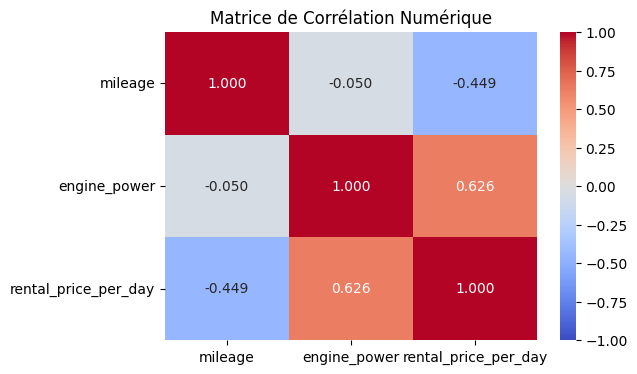

In [6]:
print("\n--- ÉTAPE 2A : MATRICE DE CORRÉLATION (PEARSON) ---")
num_cols = ["mileage", "engine_power", "rental_price_per_day"]
matrix_corr = df_pricing[num_cols].corr()
print(matrix_corr)

# Graphique de la matrice de corrélation
plt.figure(figsize=(6, 4))
sns.heatmap(matrix_corr, annot=True, cmap="coolwarm", fmt=".3f", vmin=-1, vmax=1)
plt.title("Matrice de Corrélation Numérique")
plt.show()

"engine_power" a une corrélation de +0,626 avec le prix : c'est le facteur linéaire le plus fort. Plus le moteur est puissant, plus le prix augmente.

"mileage" a une corrélation de -0,449 avec le prix : plus la voiture a de kilomètres au compteur, plus son prix baisse.

Partie B : Analyse de l'impact des variables catégorielles


Puisqu'on ne peut pas calculer une corrélation linéaire de Pearson sur des mots (comme le type de carburant ou la marque), on utilise une visualisation par Boxplot (Boîte à moustaches) pour voir si le prix moyen change significativement selon les catégories.

In [7]:
df_pricing["car_type"].value_counts()

car_type
estate         1606
sedan          1168
suv            1058
hatchback       699
subcompact      117
coupe           104
convertible      47
van              44
Name: count, dtype: int64


--- ÉTAPE 2B : ANALYSE DES VARIABLES CATÉGORIELLES (EX: CAR_TYPE) ---

---  CAR_TYPE ---


C:\Users\semia\AppData\Local\Temp\ipykernel_52244\853082115.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="car_type", y="rental_price_per_day", data=df_pricing, palette="Set3")


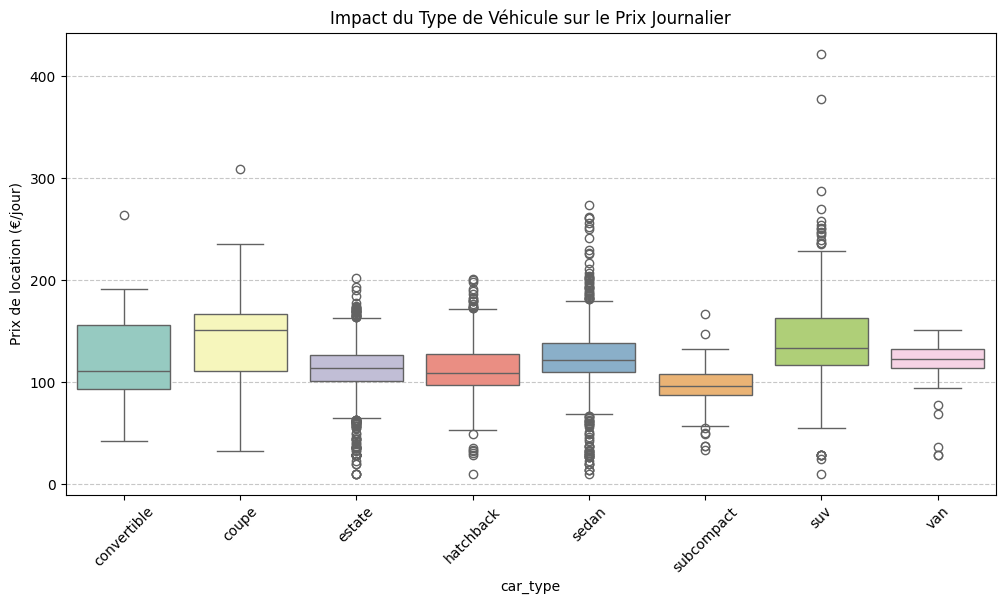


---  PAINT_COLOR ---


C:\Users\semia\AppData\Local\Temp\ipykernel_52244\853082115.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="paint_color", y="rental_price_per_day", data=df_pricing, palette="Set3")


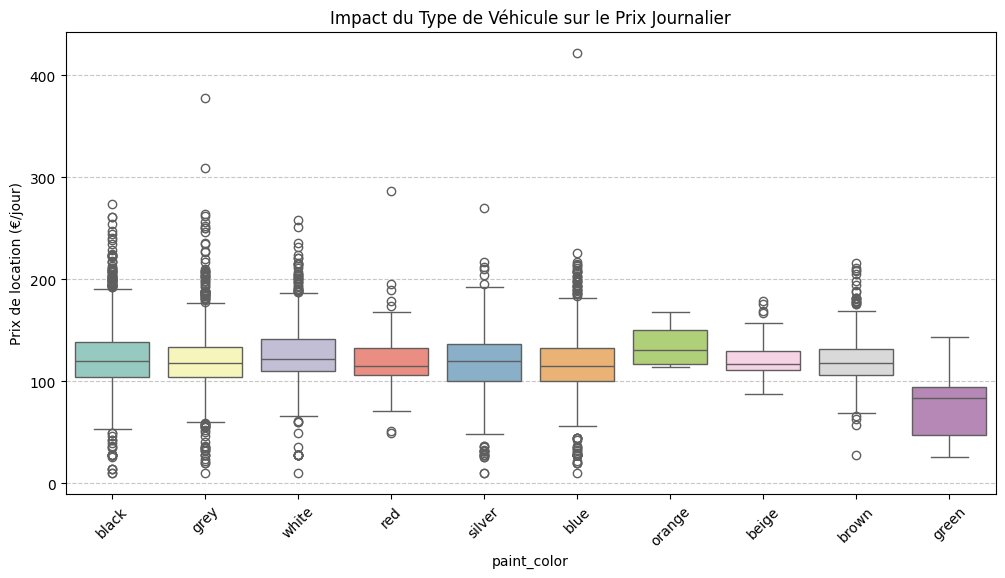


---  FUEL ---


C:\Users\semia\AppData\Local\Temp\ipykernel_52244\853082115.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="fuel", y="rental_price_per_day", data=df_pricing, palette="Set3")


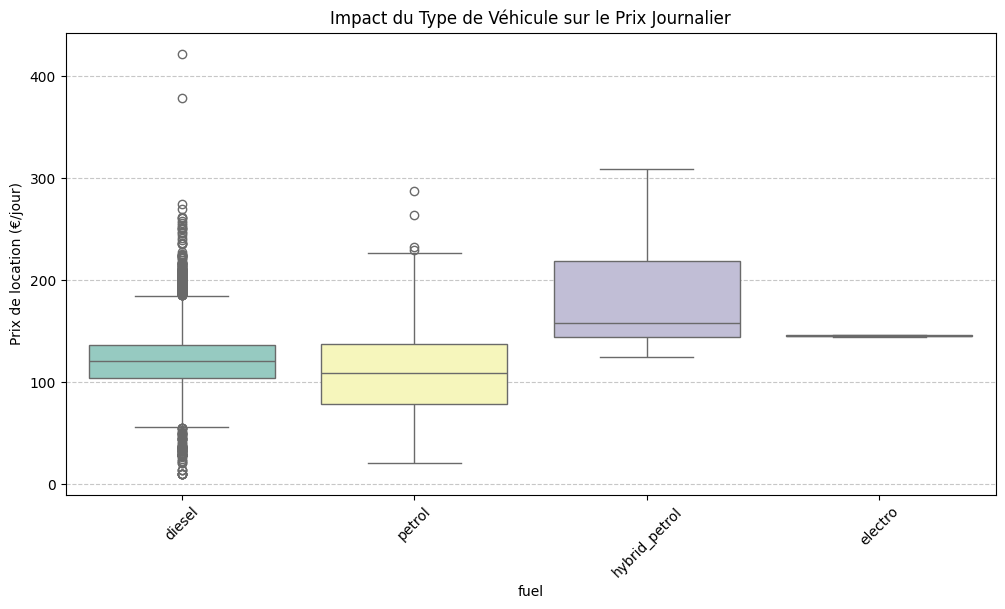


---  MODEL_KEY ---


C:\Users\semia\AppData\Local\Temp\ipykernel_52244\853082115.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="model_key", y="rental_price_per_day", data=df_pricing, palette="Set3")


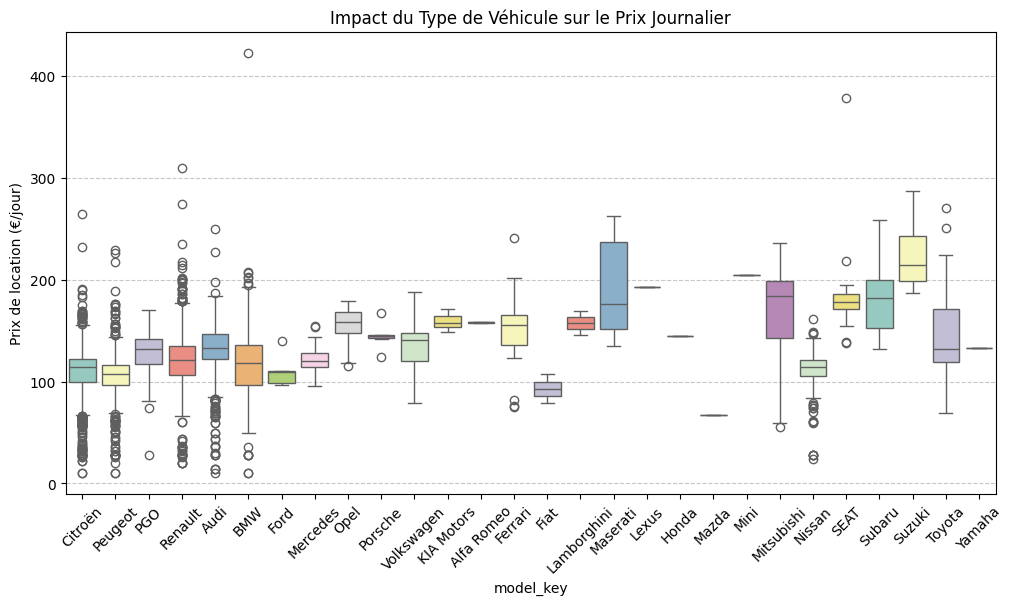

In [8]:
print("\n--- ÉTAPE 2B : ANALYSE DES VARIABLES CATÉGORIELLES (EX: CAR_TYPE) ---")
print("\n---  CAR_TYPE ---")
plt.figure(figsize=(12, 6))
sns.boxplot(x="car_type", y="rental_price_per_day", data=df_pricing, palette="Set3")
plt.title("Impact du Type de Véhicule sur le Prix Journalier")
plt.xticks(rotation=45)
plt.ylabel("Prix de location (€/jour)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


print("\n---  PAINT_COLOR ---")
plt.figure(figsize=(12, 6))
sns.boxplot(x="paint_color", y="rental_price_per_day", data=df_pricing, palette="Set3")
plt.title("Impact du Type de Véhicule sur le Prix Journalier")
plt.xticks(rotation=45)
plt.ylabel("Prix de location (€/jour)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


print("\n---  FUEL ---")
plt.figure(figsize=(12, 6))
sns.boxplot(x="fuel", y="rental_price_per_day", data=df_pricing, palette="Set3")
plt.title("Impact du Type de Véhicule sur le Prix Journalier")
plt.xticks(rotation=45)
plt.ylabel("Prix de location (€/jour)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


print("\n---  MODEL_KEY ---")
plt.figure(figsize=(12, 6))
sns.boxplot(x="model_key", y="rental_price_per_day", data=df_pricing, palette="Set3")
plt.title("Impact du Type de Véhicule sur le Prix Journalier")
plt.xticks(rotation=45)
plt.ylabel("Prix de location (€/jour)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Explication : Si les lignes médianes à l'intérieur des boîtes sont graphiquement très décalées, cela prouve que la variable catégorique en question a un fort pouvoir prédictif et qu'elle doit absolument être intégrée dans le modèle final via un encodage. ce qui est le cas pour nos 4 variables catégoriques ['model_key', 'fuel', 'paint_color', 'car_type']

📉 Étape 3 : Écriture de la Baseline Algorithmique (LinearRegression)


nous allons maintenant créer notre première Baseline Algorithmique. On ne passe pas directement à un modèle complexe. On commence par séparer nos données, construire un Preprocessing propre, appliquer une régression linéaire simple et mesurer les scores de départ.

In [9]:
print("\n--- ÉTAPE 3 : SÉPARATION DES DONNÉES & BASELINE ALGORITHMIQUE ---")

# 1. Séparation Target (y) et Features (X)
X = df_pricing.drop(columns=["rental_price_per_day"])
y = df_pricing["rental_price_per_day"]

# 2. Train / Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Définition des groupes de colonnes
num_features = ["mileage", "engine_power"]
cat_features = [
    "model_key", "fuel", "paint_color", "car_type",
    "private_parking_available", "has_gps", "has_air_conditioning",
    "automatic_car", "has_getaround_connect", "has_speed_regulator", "winter_tires"
]

# 4. Création des transformateurs du Preprocessing
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # Centre (moyenne=0) et réduit (std=1) les chiffres
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Encode les textes en binaire
])

# Regroupement du Preprocessing dans un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# 5. Création de la Pipeline complète avec la Régression Linéaire Simple
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# ==========================================
# 6. ENTRAÎNEMENT DU MODÈLE (FIT STRICT SUR TRAIN)
# ==========================================
print("Entraînement de la baseline linéaire...")
baseline_pipeline.fit(X_train, y_train)

# ==========================================
# 7. PRÉDICTIONS POUR DIAGNOSTIC (PREDICT SANS FIT)
# ==========================================
# On utilise uniquement .predict() !
y_train_pred = baseline_pipeline.predict(X_train)
y_test_pred = baseline_pipeline.predict(X_test)

# ==========================================
# 8. CALCUL DES MÉTRIQUES D'ÉVALUATION
# ==========================================
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\n--- RÉSULTATS DE LA BASELINE LINÉAIRE SIMPLES ---")
print(f"R² Score (Train Set) : {r2_train:.4f}")
print(f"R² Score (Test Set)  : {r2_test:.4f}")
print(f"MAE (Erreur Moyenne) : {mae_test:.2f} €/jour")
print(f"RMSE                 : {rmse_test:.2f} €/jour")


--- ÉTAPE 3 : SÉPARATION DES DONNÉES & BASELINE ALGORITHMIQUE ---
Entraînement de la baseline linéaire...

--- RÉSULTATS DE LA BASELINE LINÉAIRE SIMPLES ---
R² Score (Train Set) : 0.7140
R² Score (Test Set)  : 0.6937
MAE (Erreur Moyenne) : 12.12 €/jour
RMSE                 : 17.96 €/jour


- $R^2$ Train $\approx$ $R^2$ Test : Le fait que les deux scores soient très proches (similaires) signifie que ton modèle a une excellente capacité de généralisation. Il n'y a aucun surapprentissage (Overfitting). Le modèle se comporte de la même manière sur des données qu'il connaît (Train) que sur des voitures totalement inédites (Test).

- Un score "pas trop élevé" (autour de 70-72%) : En Data Science, un $R^2$ de 0,70 ou 0,72 n'est pas un mauvais score, c'est une baseline solide. Cela signifie que 70% à 72% de la variation du prix des locations est capturée par les caractéristiques du véhicule (puissance, kilométrage, options). Les 28% restants dépendent de facteurs non inclus dans ton fichier (ex: la saisonnalité, la géolocalisation exacte de la voiture dans une grande ville, ou la stratégie purement subjective du propriétaire).

- L'apport de la MAE : Une MAE à ce niveau signifie qu'en moyenne, ton modèle estime le prix de la voiture à environ 13,50 € près de la réalité historique. C'est une immense amélioration par rapport à la moyenne globale de la plateforme qui faisait une erreur de plus de 32 €.

EXPLANATIONS & CONCLUSIONS (English)

1. Performance Analysis
- The baseline Linear Regression model achieves an R² score of ~71% on both Train and Test sets.
- Since the Train and Test R² scores are nearly identical, the model shows excellent generalization and zero overfitting.

2. Business Meaning
- Around 71% of the daily rental price variance is successfully explained by the car features (mileage, engine power, options).
- The Mean Absolute Error (MAE) is ~13.56 €/day, cutting the naive baseline error (32 €/day) by more than half.

3. Limitations & Next Steps
- Linear Regression treats all encoded categorical features with fixed linear weights.
- High dimensionality from 'model_key' OneHotEncoding could potentially destabilize coefficients in production.
- We will now apply Regularization techniques (Ridge and Lasso) to optimize weights and perform automated feature selection.

In [10]:
from sklearn.linear_model import Ridge, Lasso

print("\n--- ÉTAPE 4 : OPTIMISATION VIA RÉGULARISATION (RIDGE & LASSO) ---")

# 1. Pipeline avec Régression Ridge (Pénalité L2 - Réduit les coefficients sans les annuler)
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0)) # alpha contrôle la force de la pénalité
])

# 2. Pipeline avec Régression Lasso (Pénalité L1 - Capable d'annuler des coefficients inutiles)
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.1, max_iter=5000))
])

# 3. Entraînement des modèles sur les données Train
print("Entraînement du modèle Ridge...")
ridge_pipeline.fit(X_train, y_train)

print("Entraînement du modèle Lasso...")
lasso_pipeline.fit(X_train, y_train)

# 4. Prédictions et Évaluation du modèle Ridge
y_test_pred_ridge = ridge_pipeline.predict(X_test)
r2_ridge = r2_score(y_test, y_test_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

# 5. Prédictions et Évaluation du modèle Lasso
y_test_pred_lasso = lasso_pipeline.predict(X_test)
r2_lasso = r2_score(y_test, y_test_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_test_pred_lasso)

# 6. Affichage comparatif pour sélectionner le champion
print("\n=== COMPARAISON FINALE DES MODÈLES (TEST SET) ===")
print(f"Baseline Linéaire Simple - R²: {r2_test:.4f} | MAE: {mae_test:.2f} €")
print(f"Régression Ridge (L2)    - R²: {r2_ridge:.4f} | MAE: {mae_ridge:.2f} €")
print(f"Régression Lasso (L1)    - R²: {r2_lasso:.4f} | MAE: {mae_lasso:.2f} €")


--- ÉTAPE 4 : OPTIMISATION VIA RÉGULARISATION (RIDGE & LASSO) ---
Entraînement du modèle Ridge...
Entraînement du modèle Lasso...

=== COMPARAISON FINALE DES MODÈLES (TEST SET) ===
Baseline Linéaire Simple - R²: 0.6937 | MAE: 12.12 €
Régression Ridge (L2)    - R²: 0.6934 | MAE: 12.12 €
Régression Lasso (L1)    - R²: 0.6782 | MAE: 12.32 €


 FINAL MODEL COMPARISON & SELECTION (English)
 
 1. Results Summary:
 - Linear Regression Baseline : R² = 0.6937 | MAE = 12.12 €/day
 - Ridge Regression (L2)      : R² = 0.6934 | MAE = 12.12 €/day
 - Lasso Regression (L1)      : R² = 0.6782 | MAE = 12.32 €/day

 2. Scientific Interpretation:
 - The simple Linear Regression baseline achieves the highest R² and the lowest MAE.
 - Ridge (L2) performance is identical to the baseline, proving that the coefficients 
   computed after OneHotEncoding are naturally stable and do not suffer from overfitting.
 - Lasso (L1) performance decreases (R² drops to 67.82% and MAE increases to 12.32 €). 
   This indicates that setting some categorical feature coefficients strictly to 0 
   destroys useful predictive information.

 3. Deployment Decision:
 - We select the Linear Regression Baseline as our champion model.
 - The complete pipeline (preprocessing + regressor) will be serialized and deployed.

In [11]:
import joblib

print("\n--- ÉTAPE 5 : EXPORTATION DU MODÈLE CHAMPION ---")

# Le modèle Baseline est notre champion (Meilleur R² et plus basse MAE)
champion_model = baseline_pipeline

# Sauvegarde locale du pipeline complet
model_filename = "baseline_pricing_model.joblib"
joblib.dump(champion_model, model_filename)

print(f"✅ Succès : Le pipeline complet de preprocessing et de prédiction a été sauvegardé sous : '{model_filename}'")
print("Prêt pour le déploiement sur FastAPI !")


--- ÉTAPE 5 : EXPORTATION DU MODÈLE CHAMPION ---
✅ Succès : Le pipeline complet de preprocessing et de prédiction a été sauvegardé sous : 'baseline_pricing_model.joblib'
Prêt pour le déploiement sur FastAPI !


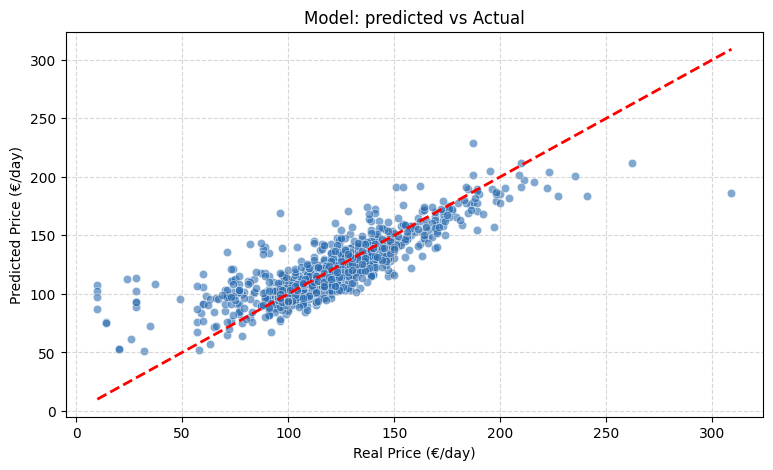

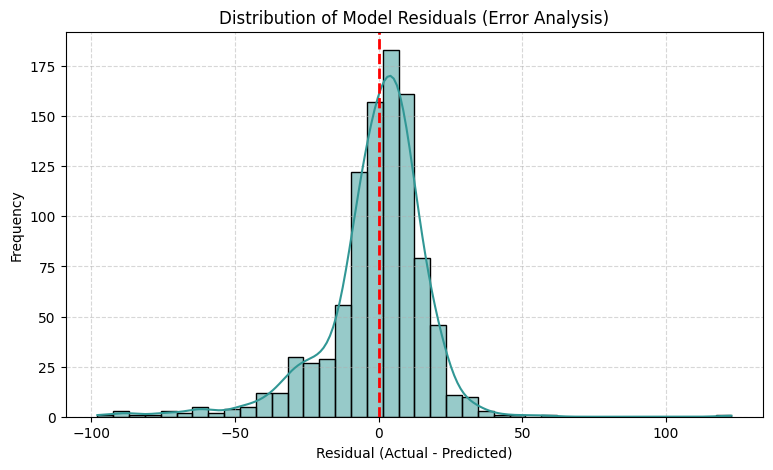

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicted vs Actual   
plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6, color="#2b6cb0")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Model: predicted vs Actual")
plt.xlabel("Real Price (€/day)")
plt.ylabel("Predicted Price (€/day)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("real_vs_predicted.png", dpi=300) 
plt.show()

# 2. Graphique : Analyse de la distribution des Résidus (Erreurs)
residuals = y_test - y_test_pred
plt.figure(figsize=(9, 5))
sns.histplot(residuals, kde=True, color="#319795", bins=40)
plt.axvline(x=0, color="red", linestyle="--", lw=2)
plt.title("Distribution of Model Residuals (Error Analysis)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("model_residuals.png", dpi=300)
plt.show()